In [1]:
# Importing dependencies

import pandas as pd
import numpy as np
import csv
import xlrd
import openpyxl
import os
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
cafe_df = pd.read_csv('dirty_cafe_sales.csv', encoding_errors='ignore')

Checking what type of data we are dealing with

In [3]:
cafe_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
cafe_df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [5]:
cafe_df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


Standarized the missing values

In [7]:
missing_data = ['UNKNOWN', 'ERROR']

cafe_df_standard = cafe_df.replace(missing_data, np.nan)

In [8]:
cafe_df_standard.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3,3.0,9.0,NaN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,NaN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [9]:
# Checking duplicated records
cafe_df_standard.duplicated().sum()

np.int64(0)

Now we need to choose what sort of cleaning method we can choose for each column

In [10]:
cafe_df_standard.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [11]:
# standardize time
cafe_df_standard['Transaction Date'] = pd.to_datetime(cafe_df_standard['Transaction Date'])

In [12]:
# drop the missing date records as the time records are random, 
# if they were sequencial we could have assigned the previous date to it
cafe_df_standard = cafe_df_standard.dropna(subset='Transaction Date')

In [13]:
cafe_df_standard['Transaction Date'].isnull().sum()

np.int64(0)

In [ ]:
# this is a wrong approach here as we can find the item name based on unit price,
# and we can drop if both unit price and item name are missing 
# the code below is bad example
# cafe_df_standard['Item'] = cafe_df_standard['Item'].fillna(cafe_df_standard['Item'].mode()[0])

#### Cleaning Items and Unit Price together as they are related

In [14]:
cafe_df_standard['Item'].unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',        nan,
 'Sandwich',    'Juice',      'Tea']
Length: 9, dtype: str

In [15]:
cafe_df_standard.shape

(9540, 8)

In [16]:
mask_unit_price_item = (
    cafe_df_standard['Item'].isna() &
    cafe_df_standard['Price Per Unit'].isna()
) 

cafe_df_standard[mask_unit_price_item]['Price Per Unit'].value_counts(dropna=False)

Price Per Unit
NaN    51
Name: count, dtype: int64

In [17]:
# removed records where both item and price per unit was null as we can not assign them
cafe_df_standard = cafe_df_standard.dropna(subset=['Item', 'Price Per Unit'], how='all')

In [18]:
cafe_df_standard.shape

(9489, 8)

In [19]:
cafe_df_standard['Price Per Unit'] = cafe_df_standard['Price Per Unit'].astype(float)
cafe_df_standard['Quantity'] = cafe_df_standard['Quantity'].astype(float)
cafe_df_standard['Total Spent'] = cafe_df_standard['Total Spent'].astype(float)

In [20]:
cafe_df_standard['Price Per Unit'].value_counts()

Price Per Unit
3.0    2319
4.0    2219
2.0    1185
5.0    1150
1.0    1088
1.5    1073
Name: count, dtype: int64

In [21]:
cafe_df_standard.groupby('Item')['Price Per Unit'].count()

Item
Cake        1031
Coffee      1069
Cookie       976
Juice       1065
Salad       1035
Sandwich    1027
Smoothie     990
Tea          965
Name: Price Per Unit, dtype: int64

In [22]:
cafe_df_standard.groupby('Item')['Price Per Unit'].unique()

Item
Cake        [3.0, nan]
Coffee      [2.0, nan]
Cookie      [1.0, nan]
Juice       [3.0, nan]
Salad       [5.0, nan]
Sandwich    [4.0, nan]
Smoothie    [4.0, nan]
Tea         [1.5, nan]
Name: Price Per Unit, dtype: object

In [23]:
cafe_df_standard[cafe_df_standard['Price Per Unit'] == 4.0]['Item'].value_counts(dropna=False)

Item
Sandwich    1027
Smoothie     990
NaN          202
Name: count, dtype: int64

In [24]:
pd.crosstab(cafe_df_standard['Item'], cafe_df_standard['Location'])
# pd.crosstab(cafe_df_standard['Item'], cafe_df_standard['Location'], normalize='columns')

Location,In-store,Takeaway
Item,,
Cake,305,329
Coffee,304,338
Cookie,313,346
Juice,348,321
Salad,351,336
Sandwich,355,323
Smoothie,305,293
Tea,306,317


In [25]:
pd.crosstab(cafe_df_standard['Item'], cafe_df_standard['Payment Method'])

Payment Method,Cash,Credit Card,Digital Wallet
Item,,,
Cake,264,240,239
Coffee,231,232,258
Cookie,234,239,250
Juice,258,264,279
Salad,273,270,228
Sandwich,241,242,242
Smoothie,223,243,244
Tea,232,219,240


`Proportional Random Assignment`

In [26]:
# You have two choices here for sandwitch and smoothie as they are equally distributed,
# 1. You can assign them unknown and preserve them and report it as such
# 2. You can assign them values based on proportional random assignment like used here

mask = (
    cafe_df_standard['Item'].isna() &
    (cafe_df_standard['Price Per Unit'] == 4)
)

cafe_df_standard.loc[mask, 'Item'] = np.random.choice(
    ['Sandwich', 'Smoothie'],  # possiblr choices
    size=mask.sum(),           # number of data on which choices would be made
    p=[1027/2017, 990/2017]    # probabilty of choices
)

In [27]:
cafe_df_standard[cafe_df_standard['Price Per Unit'] == 4.0]['Item'].value_counts(dropna=False)

Item
Sandwich    1124
Smoothie    1095
Name: count, dtype: int64

In [28]:
unit_price_map = {
    2.0: 'Coffee',
    3.0: 'Cake',
    1.0: 'Cookie',
    5.0: 'Salad',
    3.0: 'Juice',
    1.5: 'Tea'
}

cafe_df_standard['Item'] = cafe_df_standard['Item'].fillna(
    cafe_df_standard['Price Per Unit'].map(unit_price_map)
) 

In [29]:
price_map = {
    'Coffee': 2.0,
    'Cake': 3.0,
    'Cookie': 1.0,
    'Juice': 3.0,
    'Tea': 1.5,
    'Sandwich': 4.0,
    'Smoothie': 4.0,
    'Salad': 5.0
}

cafe_df_standard['Price Per Unit'] = cafe_df_standard['Price Per Unit'].fillna(
    cafe_df_standard['Item'].map(price_map)
) 


In [30]:
cafe_df_standard['Item'].isnull().sum()

np.int64(0)

In [31]:
cafe_df_standard['Price Per Unit'].isnull().sum()

np.int64(0)

In [32]:
cafe_df_standard['Price Per Unit'] = cafe_df_standard['Price Per Unit'].astype(float)

#### Now cleanung Quantity and total price as they are connected, unit orice has already been cleaned

In [33]:
cafe_df_standard['Quantity'].value_counts(dropna=False)

Quantity
5.0    1902
2.0    1884
4.0    1760
3.0    1757
1.0    1735
NaN     451
Name: count, dtype: int64

In [34]:
cafe_df_standard['Total Spent'].isnull().sum()

np.int64(473)

In [35]:
mask2 = (
    cafe_df_standard['Total Spent'].isna() &
    cafe_df_standard['Quantity'].isna()
)

cafe_df_standard[mask2]['Quantity'].value_counts(dropna=False)
cafe_df_standard[mask2]['Total Spent'].value_counts(dropna=False)
# cafe_df_standard[mask2]

Total Spent
NaN    20
Name: count, dtype: int64

In [36]:
# Justified to remove record where both Quantity and Total Spent is null
cafe_df_standard = cafe_df_standard.dropna(subset=['Quantity', 'Total Spent'], how='all')

In [37]:
cafe_df_standard[cafe_df_standard['Quantity'].isna()]['Quantity'].value_counts(dropna=False)

Quantity
NaN    431
Name: count, dtype: int64

In [38]:
cafe_df_standard[cafe_df_standard['Total Spent'].isna()]['Total Spent'].value_counts(dropna=False)

Total Spent
NaN    453
Name: count, dtype: int64

In [39]:
mask_quantity = (
    cafe_df_standard['Quantity'].notna() &
    cafe_df_standard['Total Spent'].isna() &
    cafe_df_standard['Price Per Unit'].notna()
)

cafe_df_standard.loc[mask_quantity, 'Total Spent'] = (
    cafe_df_standard.loc[mask_quantity, 'Quantity']
    * cafe_df_standard.loc[mask_quantity, 'Price Per Unit']
)

In [40]:
cafe_df_standard[cafe_df_standard['Total Spent'].isna()]['Total Spent'].value_counts(dropna=False)

Series([], Name: count, dtype: int64)

In [41]:
cafe_df_standard.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [42]:
mask3 = (
    cafe_df_standard['Quantity'].isna() &
    cafe_df_standard['Total Spent'].notna() & 
    cafe_df_standard['Price Per Unit'].notna()
)

cafe_df_standard.loc[mask3, 'Quantity'] = (
    cafe_df_standard.loc[mask3, 'Total Spent'] /
    cafe_df_standard.loc[mask3, 'Price Per Unit']
)


In [43]:
cafe_df_standard['Location'] = cafe_df_standard['Location'].fillna('UNKNOWN')
cafe_df_standard['Payment Method'] = cafe_df_standard['Payment Method'].fillna('UNKNOWN')

#### **Note that there is a vast majority of data in `Location` and `Payment Method` which is missing (~40%) so instead of filling it with mode, I left it as unknown to better clarify it in analysis**

In [ ]:
cafe_df_standard.to_csv('clean_cafe_sales2.csv', index=False)

<div align="center">

## **EDA of Cafe Sales**

</div>

In [46]:
cafe_df_standard.shape

(9469, 8)

In [47]:
cafe_df_standard.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [48]:
cafe_df_standard.info()

<class 'pandas.DataFrame'>
Index: 9469 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9469 non-null   str           
 1   Item              9469 non-null   str           
 2   Quantity          9469 non-null   float64       
 3   Price Per Unit    9469 non-null   float64       
 4   Total Spent       9469 non-null   float64       
 5   Payment Method    9469 non-null   str           
 6   Location          9469 non-null   str           
 7   Transaction Date  9469 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 665.8 KB


In [49]:
cafe_df_standard.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9469.000000,9469.000000,9469.000000,9469
mean,3.019326,2.949097,8.918418,2023-07-01 22:10:30.351674
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.420453,1.279818,6.008964,NaN


In [50]:
cafe_df_standard.duplicated().sum()

np.int64(0)

In [51]:
cafe_df_standard.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [52]:
corr = cafe_df_standard[['Price Per Unit', 'Quantity', 'Total Spent']].corr()

In [53]:
c_df = cafe_df_standard

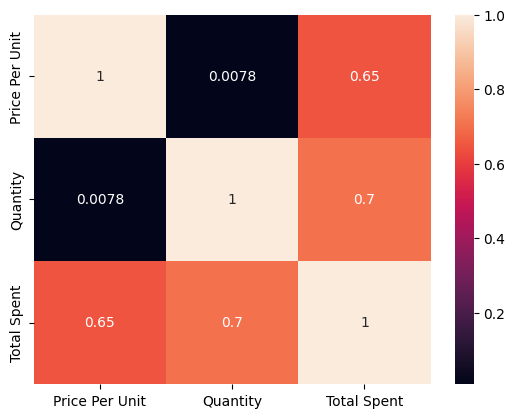

In [ ]:
sns.heatmap(data=corr, annot=True)

## **Sales Distribution**

<Axes: xlabel='Total Spent'>

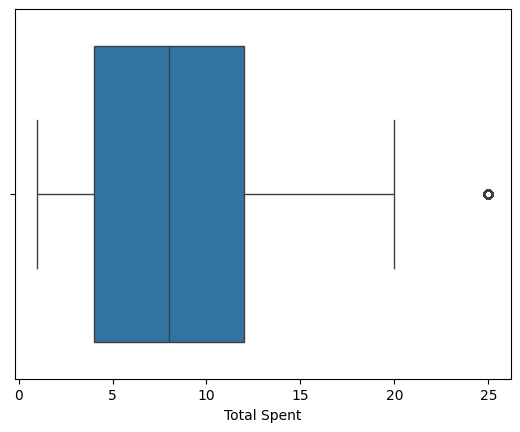

In [56]:
#checking outliers

sns.boxplot(data=c_df, x='Total Spent')

Text(0, 0.5, 'Frequency')

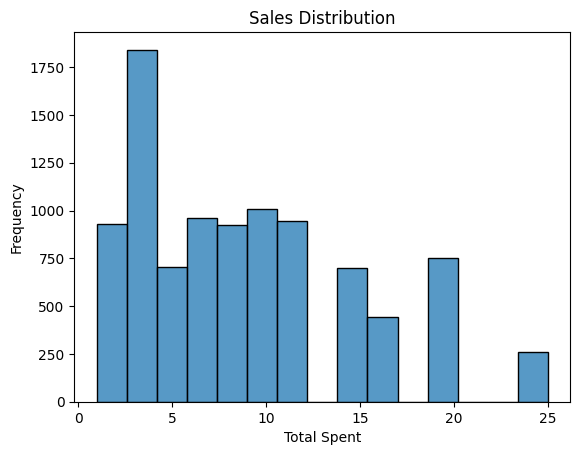

In [57]:

sns.histplot(data=c_df, x='Total Spent', bins=15)

plt.title('Sales Distribution')
plt.ylabel('Frequency')


In [58]:
total_sale_per_catg = (
    c_df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
    .reset_index(name='Total Revenue')
)

In [59]:
total_items_per_catg = (
    c_df.groupby('Item')['Quantity'].sum()
    .sort_values(ascending=False).reset_index(name='Total Quantity')
)

In [60]:
c_df.groupby('Item')['Price Per Unit'].unique()

Item
Cake        [3.0]
Coffee      [2.0]
Cookie      [1.0]
Juice       [3.0]
Salad       [5.0]
Sandwich    [4.0]
Smoothie    [4.0]
Tea         [1.5]
Name: Price Per Unit, dtype: object

In [61]:
color_map = {
    'Juice': 'C0',
    'Coffee': 'C1',
    'Salad': 'C2',
    'Sandwich': 'C3',
    'Smoothie': 'C4',
    'Tea': 'C5',
    'Cookie': 'C6',
    'Cake': 'C7'
}

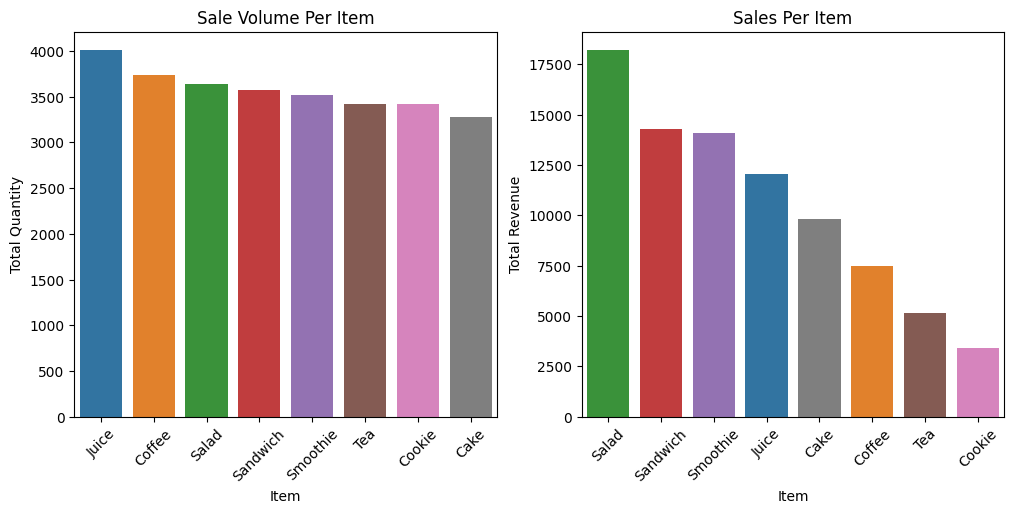

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.barplot(
    data=total_items_per_catg,
    x='Item',
    y='Total Quantity',
    hue='Item',
    palette=color_map,
    legend=False, 
    ax = ax[0]
)
ax[0].set_title('Sale Volume Per Item')

sns.barplot(
    data=total_sale_per_catg,
    x='Item',
    y='Total Revenue',
    hue='Item',
    palette=color_map,
    legend=False,
    ax = ax[1]
)
ax[1].set_title('Sales Per Item')

for a in ax:
    a.tick_params(axis='x', rotation=45)

#### *`Observation`*

Juice recorded the highest quantity sold, indicating strong customer demand. However, Salad generated the highest revenue despite selling fewer units because of its higher unit price. This suggests that revenue is influenced by both sales volume and pricing. Lower-priced items such as Coffee achieved high sales volumes but contributed less revenue compared to premium-priced products.

### **Time Based Analysis**

Text(0.5, 1.0, 'Revenue Over Time')

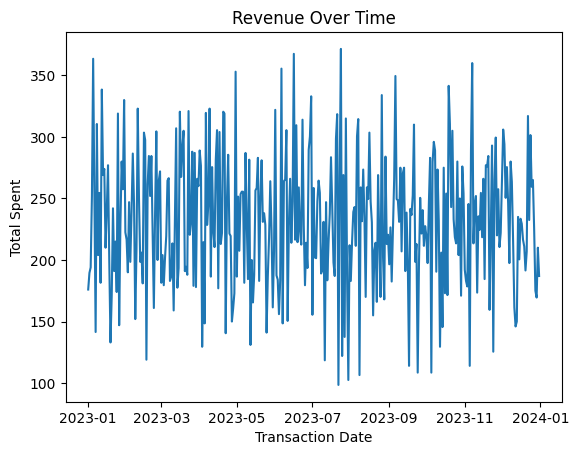

In [63]:
daily_sales = (
    c_df.groupby('Transaction Date')['Total Spent']
    .sum()
    .reset_index()
)

sns.lineplot(
    data=daily_sales,
    x='Transaction Date',
    y='Total Spent'
)
plt.title('Revenue Over Time')

In [64]:
c_df['Day'] = c_df['Transaction Date'].dt.day_name()

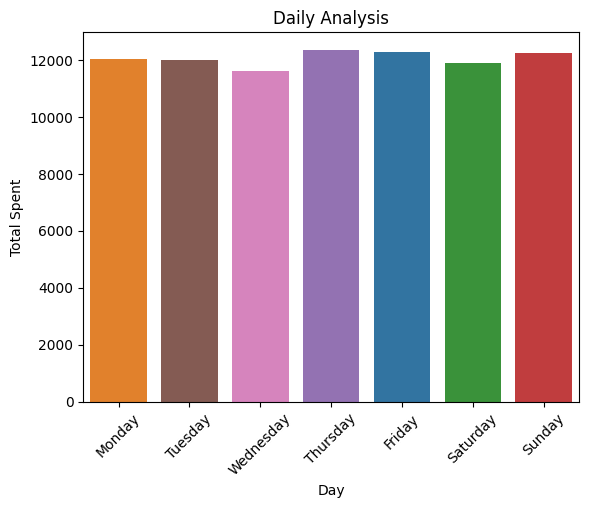

In [ ]:
day_sales = c_df.groupby('Day')['Total Spent'].sum().reset_index()

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

fig, ax = plt.subplots()

sns.barplot(
    data=day_sales,
    x='Day',
    y='Total Spent',
    hue='Day',
    order=day_order,
    ax = ax
)
ax.set_title('Daily Analysis')
ax.tick_params(axis='x', rotation=45)

In [69]:
df = c_df

In [70]:
df['Month'] = df['Transaction Date'].dt.month_name()

df['Month_Num'] = df['Transaction Date'].dt.month

monthly_sales = (
    df.groupby(['Month_Num', 'Month'])['Total Spent']
      .sum()
      .reset_index()
      .sort_values('Month_Num')
)

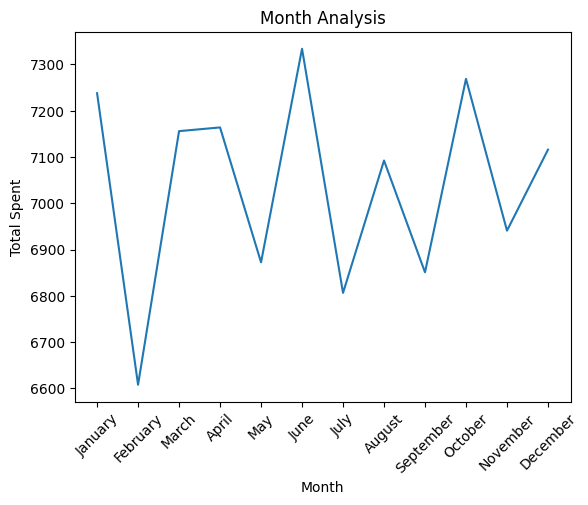

In [ ]:
fig, ax = plt.subplots()

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Total Spent',
    ax = ax
)
ax.set_title('Month Analysis')
ax.tick_params(axis='x', rotation=45)

#### `Observation`

Revenue appears relatively stable across the days of the week, with Thursday showing the highest sales and Wednesday the lowest.